In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [39]:
df = pd.read_csv("Metro_Interstate_Traffic_Volume.csv")

In [40]:
print(df.head())

  holiday    temp  rain_1h  snow_1h  clouds_all weather_main  \
0     NaN  288.28      0.0      0.0          40       Clouds   
1     NaN  289.36      0.0      0.0          75       Clouds   
2     NaN  289.58      0.0      0.0          90       Clouds   
3     NaN  290.13      0.0      0.0          90       Clouds   
4     NaN  291.14      0.0      0.0          75       Clouds   

  weather_description            date_time  traffic_volume  
0    scattered clouds  2012-10-02 09:00:00            5545  
1       broken clouds  2012-10-02 10:00:00            4516  
2     overcast clouds  2012-10-02 11:00:00            4767  
3     overcast clouds  2012-10-02 12:00:00            5026  
4       broken clouds  2012-10-02 13:00:00            4918  


In [41]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   holiday              61 non-null     object 
 1   temp                 48204 non-null  float64
 2   rain_1h              48204 non-null  float64
 3   snow_1h              48204 non-null  float64
 4   clouds_all           48204 non-null  int64  
 5   weather_main         48204 non-null  object 
 6   weather_description  48204 non-null  object 
 7   date_time            48204 non-null  object 
 8   traffic_volume       48204 non-null  int64  
dtypes: float64(3), int64(2), object(4)
memory usage: 3.3+ MB
None


In [42]:
df = df[[
    'date_time',
    'traffic_volume',
    'temp',
    'rain_1h',
    'snow_1h',
    'clouds_all'
]]

In [43]:
df['date_time'] = pd.to_datetime(df['date_time'])

df['hour'] = df['date_time'].dt.hour
df['day'] = df['date_time'].dt.dayofweek
df['month'] = df['date_time'].dt.month

df.set_index('date_time', inplace=True)

In [ ]:
df.fillna(method='ffill', inplace=True)

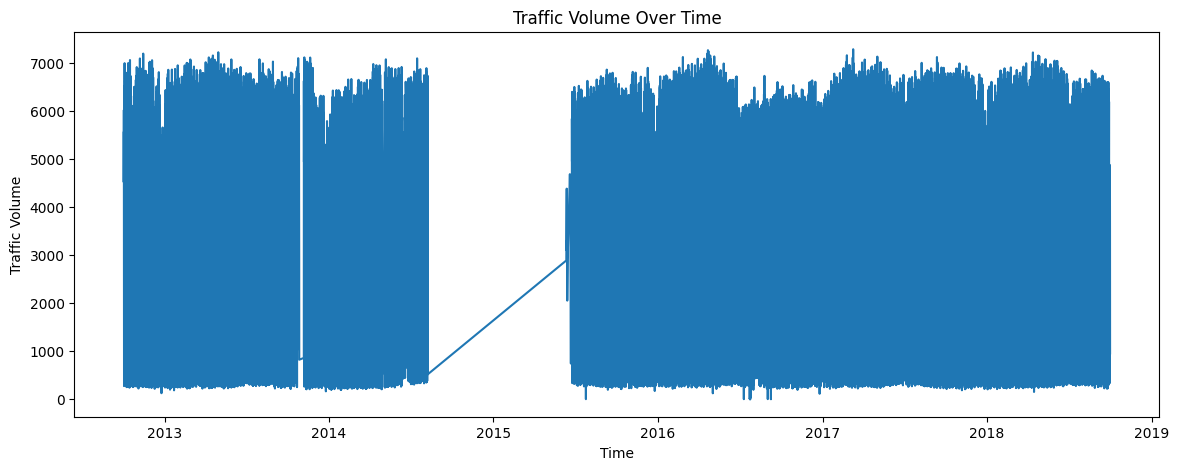

In [60]:
plt.figure(figsize=(14,5))
plt.plot(df['traffic_volume'])
plt.title("Traffic Volume Over Time")
plt.xlabel("Time")
plt.ylabel("Traffic Volume")
plt.show()

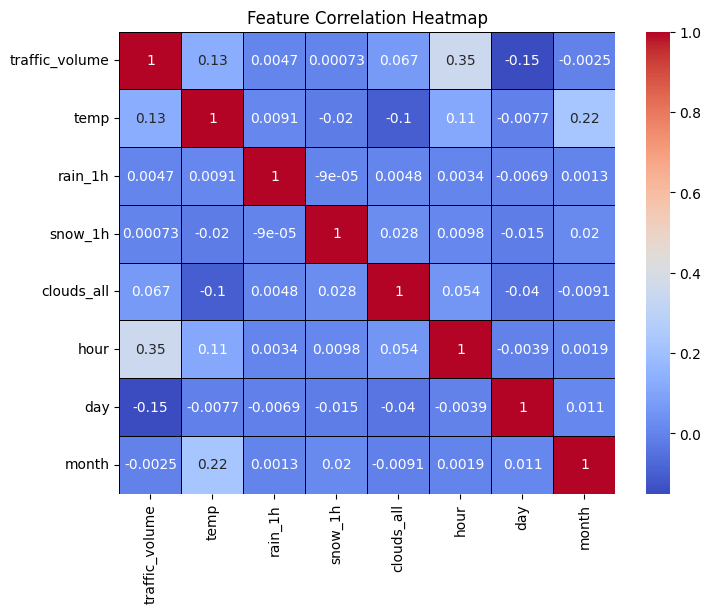

In [61]:
plt.figure(figsize=(8,6))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm', linewidths=0.5, linecolor='black')

plt.title("Feature Correlation Heatmap")
plt.show()

In [47]:
scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(df)

In [59]:
def create_sequences(data, seq_length=24):
    X = []
    y = []

    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length, 0])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data)

In [49]:
split = int(0.8 * len(X))

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [ ]:
model = Sequential()
model.add(
    LSTM(
        128,
        return_sequences=True,
        input_shape=(X.shape[1], X.shape[2])
    )
)

model.add(Dropout(0.2))
model.add(LSTM(64))
model.add(Dropout(0.2))
model.add(Dense(32, activation='relu'))
model.add(Dense(1))
model.compile(
    optimizer='adam',
    loss='mse'
)

In [51]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [52]:
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

Epoch 1/30
603/603 ━━━━━━━━━━━━━━━━━━━━ 20s 25ms/step - loss: 0.0215 - val_loss: 0.0048
Epoch 2/30
603/603 ━━━━━━━━━━━━━━━━━━━━ 29s 49ms/step - loss: 0.0089 - val_loss: 0.0056
Epoch 3/30
603/603 ━━━━━━━━━━━━━━━━━━━━ 17s 28ms/step - loss: 0.0077 - val_loss: 0.0040
Epoch 4/30
603/603 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - loss: 0.0071 - val_loss: 0.0037
Epoch 5/30
603/603 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - loss: 0.0067 - val_loss: 0.0035
Epoch 6/30
603/603 ━━━━━━━━━━━━━━━━━━━━ 14s 24ms/step - loss: 0.0064 - val_loss: 0.0034
Epoch 7/30
603/603 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - loss: 0.0061 - val_loss: 0.0034
Epoch 8/30
603/603 ━━━━━━━━━━━━━━━━━━━━ 14s 24ms/step - loss: 0.0060 - val_loss: 0.0032
Epoch 9/30
603/603 ━━━━━━━━━━━━━━━━━━━━ 14s 24ms/step - loss: 0.0057 - val_loss: 0.0030
Epoch 10/30
603/603 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - loss: 0.0056 - val_loss: 0.0029
Epoch 11/30
603/603 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - loss: 0.0055 - val_loss: 0.0033
Epoch 12/30
603/603 ━━━━━━━━━━

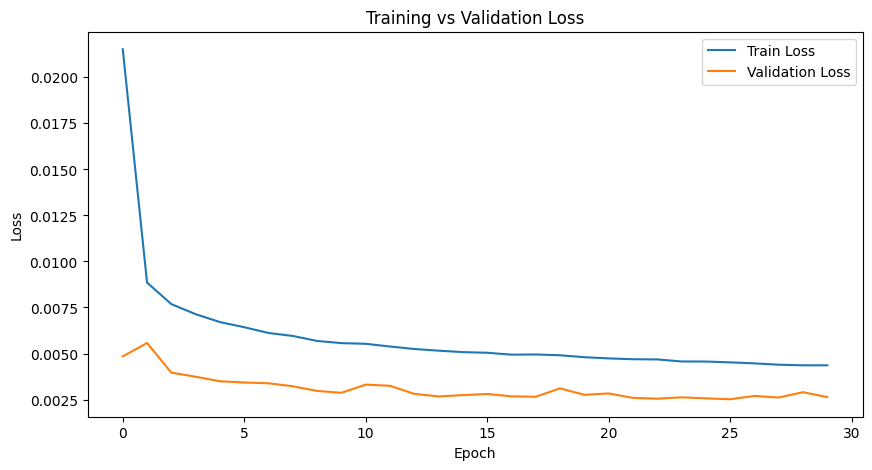

In [53]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.show()

In [54]:
predictions = model.predict(X_test)

302/302 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


In [55]:
dummy_pred = np.zeros((len(predictions), scaled_data.shape[1]))
dummy_test = np.zeros((len(y_test), scaled_data.shape[1]))

dummy_pred[:,0] = predictions.flatten()
dummy_test[:,0] = y_test.flatten()

pred_actual = scaler.inverse_transform(dummy_pred)[:,0]
y_actual = scaler.inverse_transform(dummy_test)[:,0]

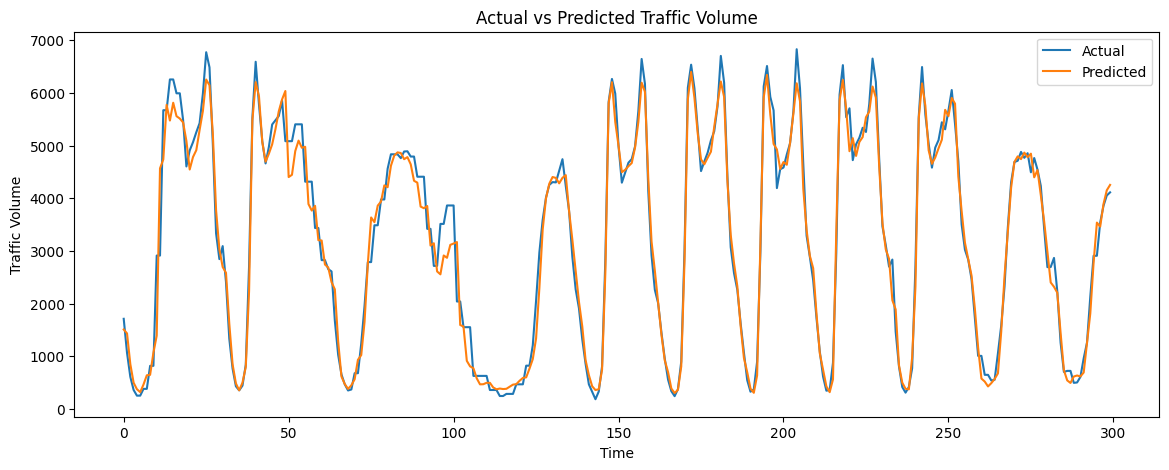

In [56]:
plt.figure(figsize=(14,5))

plt.plot(y_actual[:300], label='Actual')
plt.plot(pred_actual[:300], label='Predicted')

plt.title("Actual vs Predicted Traffic Volume")
plt.xlabel("Time")
plt.ylabel("Traffic Volume")

plt.legend()
plt.show()

In [57]:
mse = mean_squared_error(y_actual, pred_actual)
mae = mean_absolute_error(y_actual, pred_actual)
rmse = np.sqrt(mse)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)

MAE : 242.7402939616075
MSE : 133441.00603021058
RMSE: 365.2957788288972
